#                                                                  Cairo Housing Market Analysis
## Factors Influencing Residential Property Prices in Cairo, Egypt
---
**Course:** C-DE211: Data Analysis  
**Dataset:** Egypt Cairo Housing Prices — Kaggle  
**Team:** [Team GB]  

### Research Questions:
- Does **property type** significantly affect price? *(T-test)*
- Does **property size (m²)** correlate strongly with price? *(Correlation)*
- Does **number of bedrooms** significantly affect price? *(ANOVA)*

---
## Section 1: Importing Libraries

In [4]:
# ── Core Libraries ──────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Statistical Testing ──────────────────────────────────────
from scipy import stats
from scipy.stats import ttest_ind, f_oneway, pearsonr, spearmanr

# ── Display Settings ─────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Plot Style ───────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14

---
## Section 2: Loading the Dataset

In [5]:
# ── Load Dataset ─────────────────────────────────────────────
df = pd.read_csv("properties.csv")

print("Dataset loaded successfully")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded successfully
Shape: 11,418 rows × 7 columns


### First Look at the Data

In [6]:
df.head(10)

,type,title,location,bedroom,bathroom,size_sqm,price
0,Duplex,Prime Location Duplex Fully Finished With A\C,"Park View, North Investors Area, New Cairo Cit...",4,4,345,"6,850,000"
1,Villa,Town house resale at Mivida Emaar with best price,"Mivida, 5th Settlement Compounds, The 5th Sett...",3,3,285,"10,000,000"
2,Apartment,Lake View Residence - Apartment | Prime Location,"Lake View Residence, 5th Settlement Compounds,...",3,3,210,"5,700,000"
3,Townhouse,Best Penthouse for sale in villette ( sky conds ),"La Vista City, New Capital Compounds, New Capi...",4,4,230,"7,510,000"
4,Penthouse,2nd Floor | Fully Finished | Lowest Price |Par...,"Villette, 5th Settlement Compounds, The 5th Se...",5,6,284,"8,511,300"
5,Apartment,Amazing Delivered Villa Below market price at...,"Tag Sultan, Ring Road, Cairo",3,2,172,"3,150,000"
6,Villa,Under market Price Apart. In tag sultan for sale,"Cairo Festival City, North Investors Area, New...",5,4,250,"3,500,000"
7,Townhouse,Apartment with installments at Lake View Resid...,"Taj City, 5th Settlement Compounds, The 5th Se...",4,4,220,"6,100,000"
8,Apartment,0% DP over 9 y f.finished apartment for sale,"Tag Sultan, Ring Road, Cairo",2,2,114,"2,278,506"
9,Apartment,Villa Modern Hyde Park 327M under market price,"Lake View Residence, 5th Settlement Compounds,...",3,3,204,"4,112,700"


In [7]:
print("Dataset Info:")
print("─" * 45)
df.info()

Dataset Info:
─────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11418 entries, 0 to 11417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   type      11418 non-null  object
 1   title     11418 non-null  object
 2   location  11418 non-null  object
 3   bedroom   11418 non-null  object
 4   bathroom  11418 non-null  int64 
 5   size_sqm  11418 non-null  object
 6   price     11418 non-null  object
dtypes: int64(1), object(6)
memory usage: 624.6+ KB


In [8]:
print("Basic Statistics:")
print("─" * 45)
df.describe(include='all')

Basic Statistics:
─────────────────────────────────────────────


,type,title,location,bedroom,bathroom,size_sqm,price
count,11418,11418,11418,11418,11418.00,11418,11418
unique,10,9941,803,10,NaN,718,2497
top,Apartment,Villa for sale In Lake View L:600 BUE:550 pric...,"Madinaty, Cairo",3,NaN,200,Ask
freq,5848,14,660,5632,NaN,279,412
mean,NaN,NaN,NaN,NaN,3.33,NaN,NaN
std,NaN,NaN,NaN,NaN,1.31,NaN,NaN
min,NaN,NaN,NaN,NaN,1.00,NaN,NaN
25%,NaN,NaN,NaN,NaN,2.00,NaN,NaN
50%,NaN,NaN,NaN,NaN,3.00,NaN,NaN
75%,NaN,NaN,NaN,NaN,4.00,NaN,NaN


In [9]:
print("Missing Values Check:")
print("─" * 45)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %'     : missing_pct
})

print(missing_df)
print("─" * 45)
print(f"Total missing values: {df.isnull().sum().sum()}")

Missing Values Check:
─────────────────────────────────────────────
          Missing Count  Missing %
type                  0       0.00
title                 0       0.00
location              0       0.00
bedroom               0       0.00
bathroom              0       0.00
size_sqm              0       0.00
price                 0       0.00
─────────────────────────────────────────────
Total missing values: 0


In [10]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

if duplicates == 0:
    print("No duplicate rows found.")
else:
    print(f"Found {duplicates} duplicate rows — will be handled in cleaning.")

Duplicate rows: 308
Found 308 duplicate rows — will be handled in cleaning.


---
##  Section 3: Data Cleaning & Preprocessing

### Step 1 — Remove Duplicate Rows

In [11]:
before = len(df)
df = df.drop_duplicates()
after = len(df)

print(f"Removed {before - after} duplicate rows.")
print(f"Remaining rows: {after:,}")

Removed 308 duplicate rows.
Remaining rows: 11,110


### Step 2 — Convert `price` to Numeric & Remove "Ask" Entries
> Some listings have price = "Ask" meaning the seller didn't post a real price.  
> These rows are useless for analysis — we drop them.

In [12]:
# Remove rows where price is "Ask" or any non-numeric value
ask_count = df[df['price'].str.strip().str.lower() == 'ask'].shape[0]
print(f"Rows with price = 'Ask': {ask_count}")

df = df[df['price'].str.strip().str.lower() != 'ask']

# Remove commas and convert to integer
df['price'] = df['price'].str.replace(',', '', regex=False).astype(int)

print(f"price column converted to numeric.")
print(f"Remaining rows: {len(df):,}")

Rows with price = 'Ask': 402
price column converted to numeric.
Remaining rows: 10,708


### Step 3 — Convert `size_sqm` to Numeric

In [13]:
df['size_sqm'] = df['size_sqm'].str.replace(',', '', regex=False)
df['size_sqm'] = pd.to_numeric(df['size_sqm'], errors='coerce')

# Drop any rows where size couldn't be converted
dropped = df['size_sqm'].isnull().sum()
df = df.dropna(subset=['size_sqm'])
df['size_sqm'] = df['size_sqm'].astype(int)

print(f"Rows dropped (unconvertible size): {dropped}")
print(f"size_sqm column converted to numeric.")

Rows dropped (unconvertible size): 0
size_sqm column converted to numeric.


### Step 4 — Clean `bedroom` Column
> Replace "Studio" with 0, remove any invalid entries.

In [14]:
print("Bedroom values before cleaning:")
print(df['bedroom'].value_counts())

# Replace Studio → 0, remove invalid
df['bedroom'] = df['bedroom'].replace('Studio', '0')
df['bedroom'] = df['bedroom'].str.replace(r'[^0-9]', '', regex=True)
df = df[df['bedroom'] != '']
df['bedroom'] = df['bedroom'].astype(int)

print("\nBedroom values after cleaning:")
print(df['bedroom'].value_counts().sort_index())

Bedroom values before cleaning:
bedroom
3         5290
4         2308
2         1393
5          933
6          353
8          172
1          133
7           91
Studio      34
{0}          1
Name: count, dtype: int64

Bedroom values after cleaning:
bedroom
0      35
1     133
2    1393
3    5290
4    2308
5     933
6     353
7      91
8     172
Name: count, dtype: int64


### Step 5 — Final Cleaned Dataset Summary

In [15]:
print("Cleaning Complete, Final Dataset Summary:")
print("─" * 45)
print(f"  Total rows       : {len(df):,}")
print(f"  Total columns    : {df.shape[1]}")
print(f"  Missing values   : {df.isnull().sum().sum()}")
print("─" * 45)
print("\nData Types:")
print(df.dtypes)
print("\nNumeric Statistics:")
df[['price', 'size_sqm', 'bedroom', 'bathroom']].describe()

Cleaning Complete, Final Dataset Summary:
─────────────────────────────────────────────
  Total rows       : 10,708
  Total columns    : 7
  Missing values   : 0
─────────────────────────────────────────────

Data Types:
type        object
title       object
location    object
bedroom      int64
bathroom     int64
size_sqm     int64
price        int64
dtype: object

Numeric Statistics:


,price,size_sqm,bedroom,bathroom
count,10708.00,10708.00,10708.00,10708.00
mean,6960465.75,12212.93,3.44,3.32
std,9223469.08,452781.57,1.19,1.31
min,1000000.00,1.00,0.00,1.00
25%,2500000.00,165.00,3.00,2.00
50%,4050000.00,220.00,3.00,3.00
75%,8000000.00,326.00,4.00,4.00
max,418252716.00,26650000.00,8.00,8.00


### Step 6 — Remove Outliers from `size_sqm` and `price`
> Extreme outliers are likely data entry errors (e.g. size = 26,650,000 m²).  
> We use the IQR method to remove them from both columns.

In [16]:
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    filtered = dataframe[(dataframe[column] >= lower) & (dataframe[column] <= upper)]
    removed = len(dataframe) - len(filtered)
    print(f"  {column}: removed {removed} outliers | valid range [{lower:,.0f} — {upper:,.0f}]")
    return filtered

print("Removing outliers using IQR method:")
print("-" * 50)
before = len(df)
df = remove_outliers_iqr(df, 'price')
df = remove_outliers_iqr(df, 'size_sqm')
df = df.reset_index(drop=True)
print("-" * 50)
print(f"Rows before: {before:,}")
print(f"Rows after : {len(df):,}")
print(f"Removed    : {before - len(df):,} outlier rows")

Removing outliers using IQR method:
--------------------------------------------------
  price: removed 896 outliers | valid range [-5,750,000 — 16,250,000]
  size_sqm: removed 603 outliers | valid range [-33 — 487]
--------------------------------------------------
Rows before: 10,708
Rows after : 9,209
Removed    : 1,499 outlier rows


---
##  Section 4: Exploratory Data Analysis (EDA)

### 4.1 Distribution of Property Types
> How many listings exist per property type?

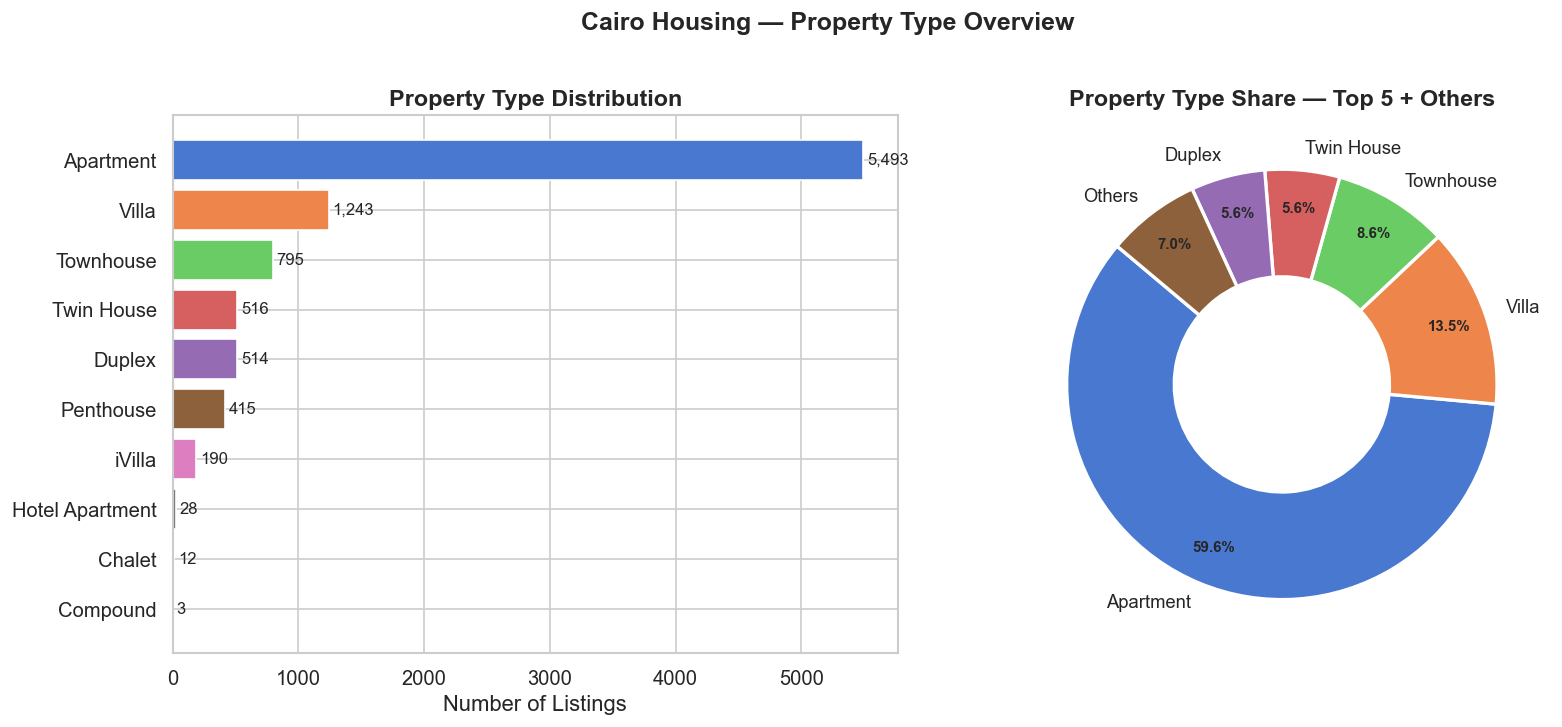

Plot saved.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

type_counts = df['type'].value_counts()
colors = sns.color_palette("muted", len(type_counts))

# -- Bar chart
axes[0].barh(type_counts.index, type_counts.values, color=colors)
axes[0].set_xlabel("Number of Listings")
axes[0].set_title("Property Type Distribution")
axes[0].invert_yaxis()
for i, v in enumerate(type_counts.values):
    axes[0].text(v + 30, i, f"{v:,}", va='center', fontsize=10)

# -- Donut chart (top 5 + Others grouped)
top5 = type_counts.head(5)
others_count = type_counts.iloc[5:].sum()
donut_data = pd.concat([top5, pd.Series({'Others': others_count})])
donut_colors = sns.color_palette("muted", len(donut_data))

wedges, texts, autotexts = axes[1].pie(
    donut_data.values,
    labels=donut_data.index,
    autopct='%1.1f%%',
    colors=donut_colors,
    startangle=140,
    pctdistance=0.82,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.5}
)

for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')

axes[1].set_title("Property Type Share — Top 5 + Others")

plt.suptitle("Cairo Housing — Property Type Overview", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("plot_01_property_type.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

### 4.2 Price Distribution
> What does the price spread look like across all listings?

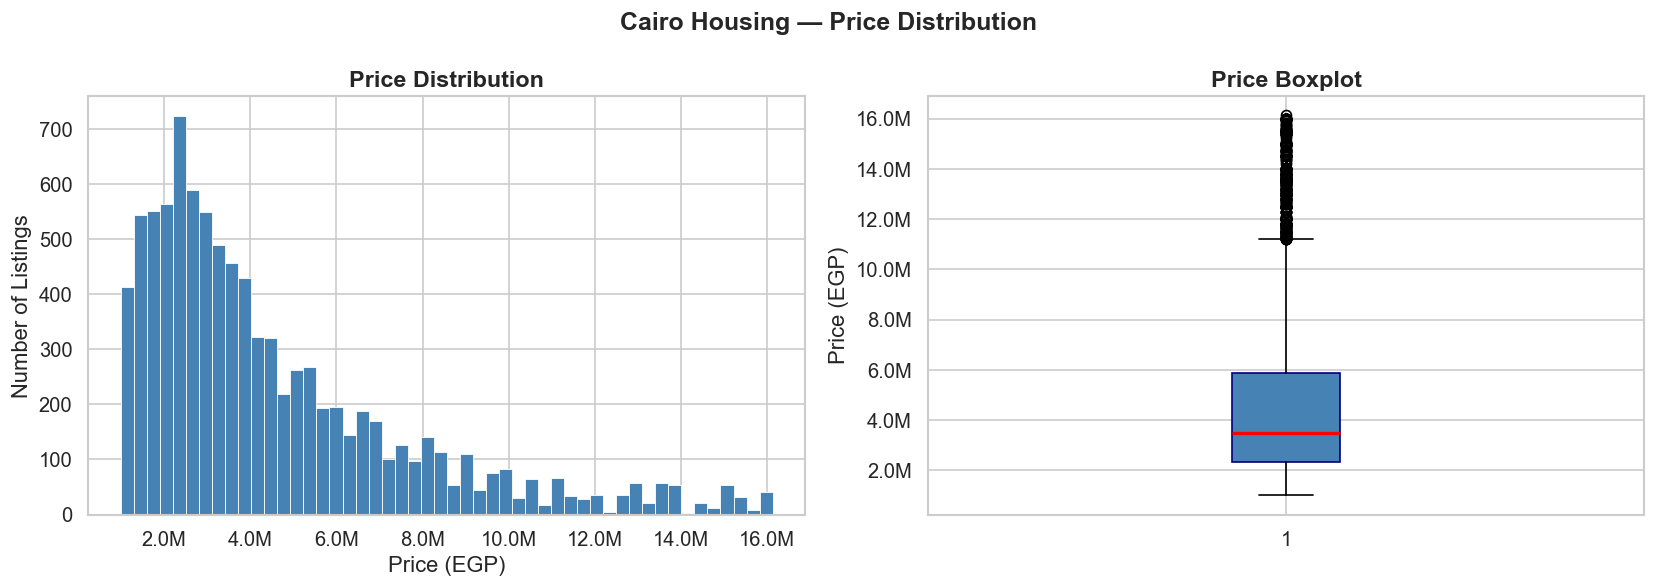

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Histogram
axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price (EGP)")
axes[0].set_ylabel("Number of Listings")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# -- Boxplot
axes[1].boxplot(df['price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title("Price Boxplot")
axes[1].set_ylabel("Price (EGP)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle("Cairo Housing — Price Distribution", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_02_price_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Size Distribution (m²)
> What is the typical property size in Cairo?

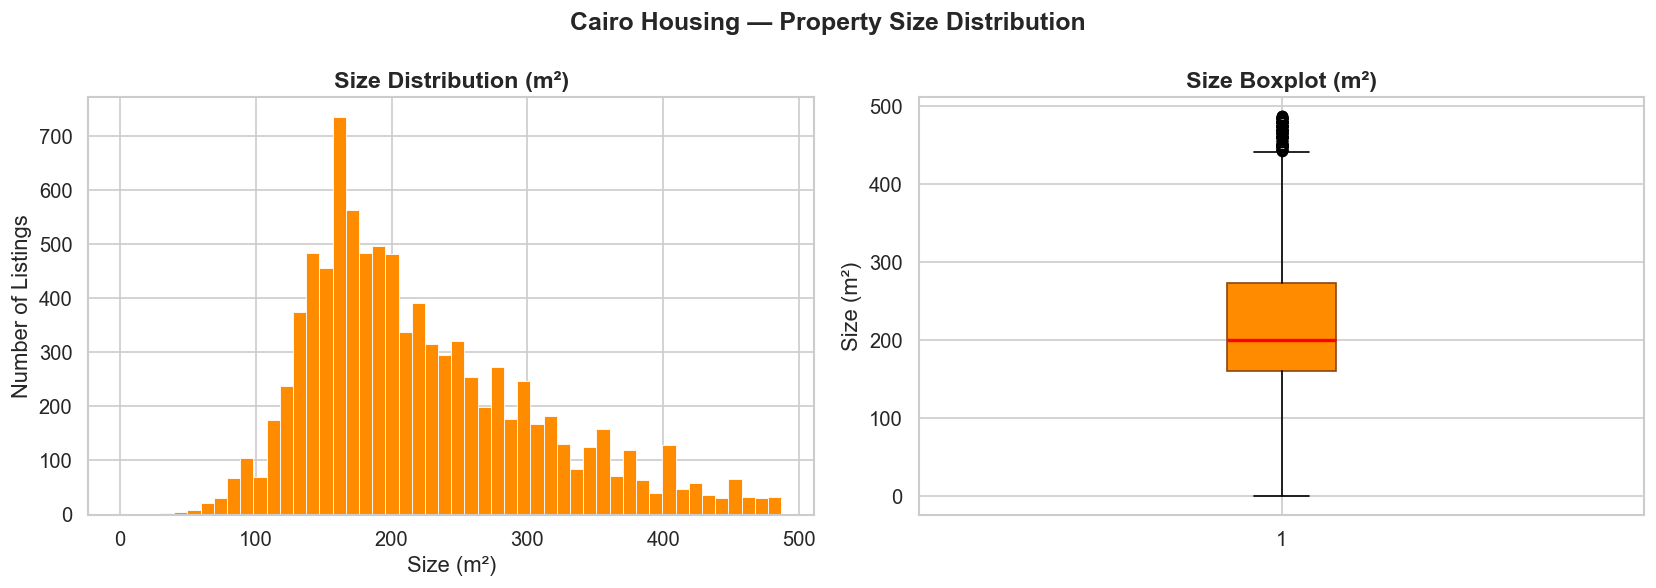

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Histogram
axes[0].hist(df['size_sqm'], bins=50, color='darkorange', edgecolor='white', linewidth=0.5)
axes[0].set_title("Size Distribution (m²)")
axes[0].set_xlabel("Size (m²)")
axes[0].set_ylabel("Number of Listings")

# -- Boxplot
axes[1].boxplot(df['size_sqm'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='darkorange', color='saddlebrown'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title("Size Boxplot (m²)")
axes[1].set_ylabel("Size (m²)")

plt.suptitle("Cairo Housing — Property Size Distribution", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_03_size_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Average Price by Property Type
> Which property type commands the highest price on average?

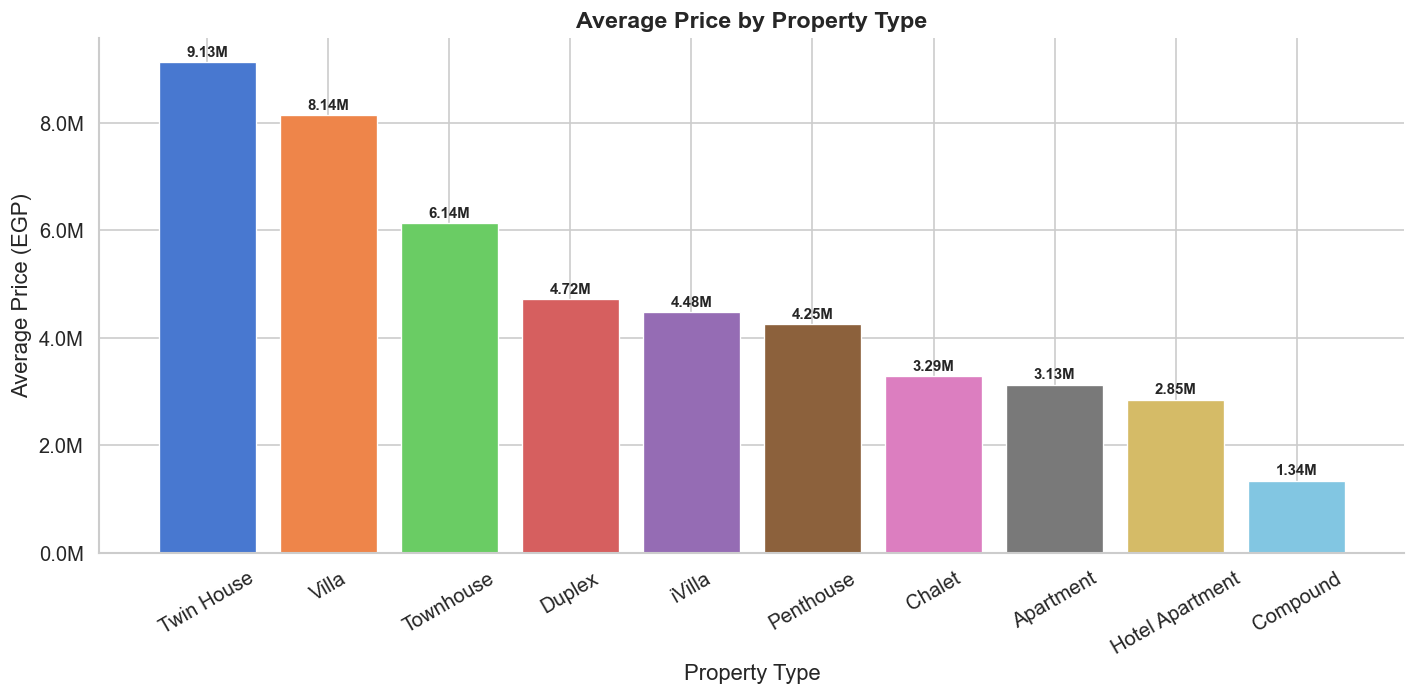

In [20]:
avg_price_type = df.groupby('type')['price'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    avg_price_type.index,
    avg_price_type.values,
    color=sns.color_palette("muted", len(avg_price_type)),
    edgecolor='white',
    linewidth=0.8
)

# Add value labels on top of each bar
for bar, val in zip(bars, avg_price_type.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50000,
        f'{val/1e6:.2f}M',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_title("Average Price by Property Type", fontsize=14, fontweight='bold')
ax.set_xlabel("Property Type")
ax.set_ylabel("Average Price (EGP)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.tick_params(axis='x', rotation=30)
sns.despine()

plt.tight_layout()
plt.savefig("plot_04_avg_price_by_type.png", dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Price Distribution per Property Type (Boxplot)
> Not just the average — how spread is the price within each type?

C:\Users\HP\AppData\Local\Temp\ipykernel_15276\241850528.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


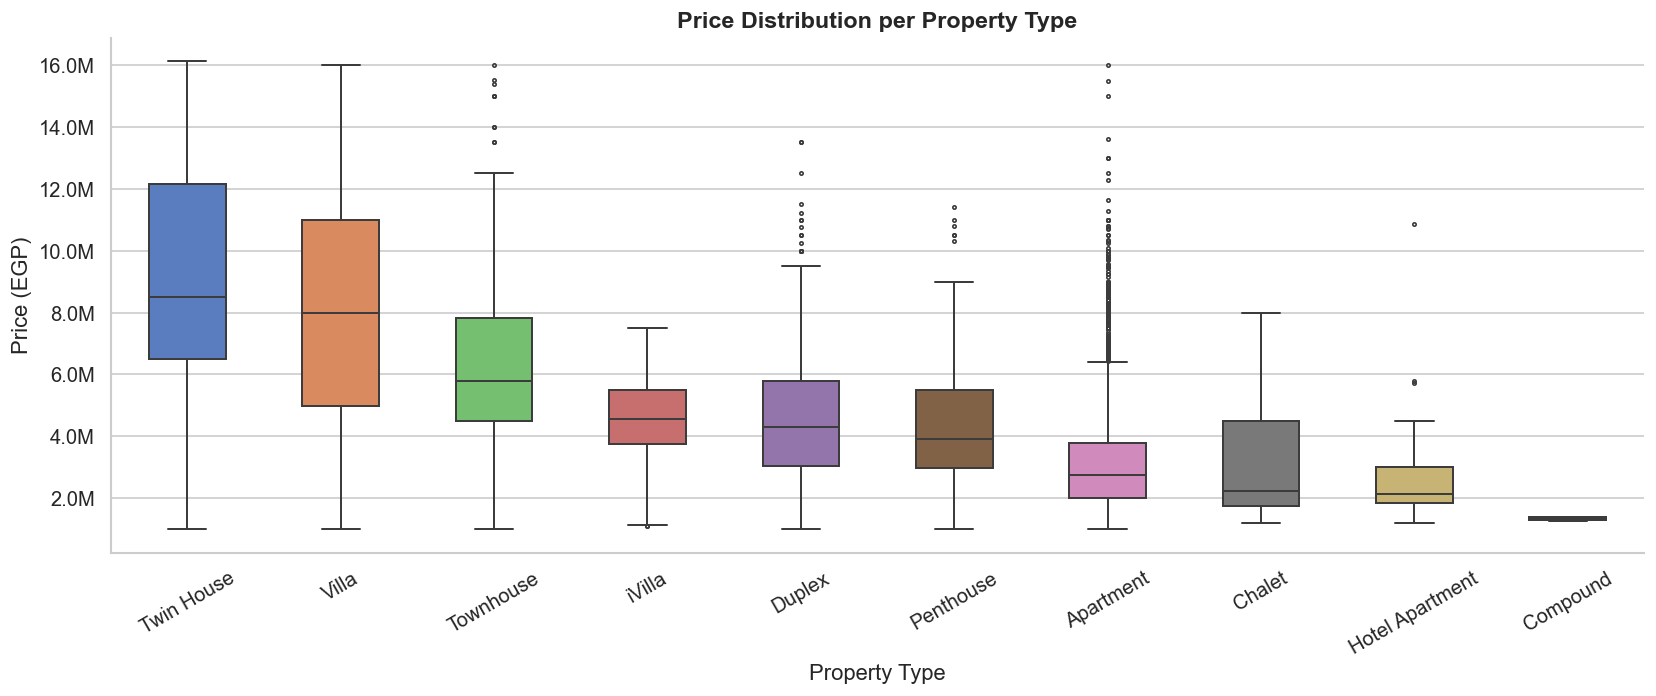

Plot saved.


In [21]:
order = df.groupby('type')['price'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=df,
    x='type', y='price',
    order=order,
    palette="muted",
    width=0.5,
    linewidth=1.2,
    fliersize=2,
    ax=ax
)

ax.set_title("Price Distribution per Property Type", fontsize=14, fontweight='bold')
ax.set_xlabel("Property Type")
ax.set_ylabel("Price (EGP)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.tick_params(axis='x', rotation=30)
sns.despine()

plt.tight_layout()
plt.savefig("plot_05_price_boxplot_by_type.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

### 4.6 Number of Listings per Bedroom Count
> How many bedrooms do most Cairo properties have?

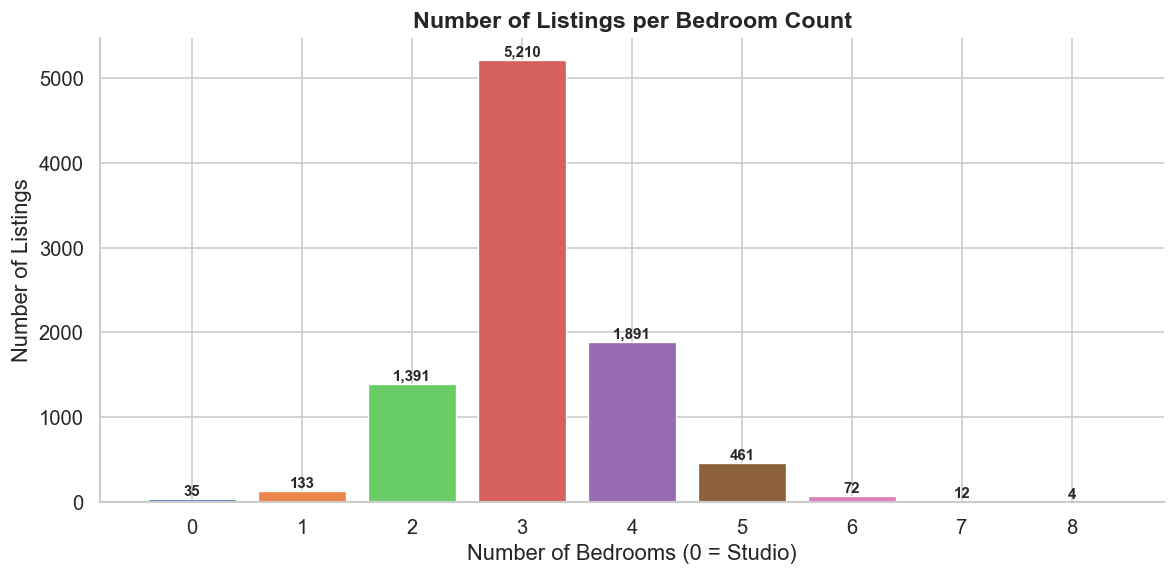

Plot saved.


In [22]:
bedroom_counts = df['bedroom'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    bedroom_counts.index.astype(str),
    bedroom_counts.values,
    color=sns.color_palette("muted", len(bedroom_counts)),
    edgecolor='white',
    linewidth=0.8
)

for bar, val in zip(bars, bedroom_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f'{val:,}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_title("Number of Listings per Bedroom Count", fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Bedrooms (0 = Studio)")
ax.set_ylabel("Number of Listings")
sns.despine()

plt.tight_layout()
plt.savefig("plot_06_bedroom_counts.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

### 4.7 Average Price by Number of Bedrooms
> Does adding more bedrooms mean a higher price?

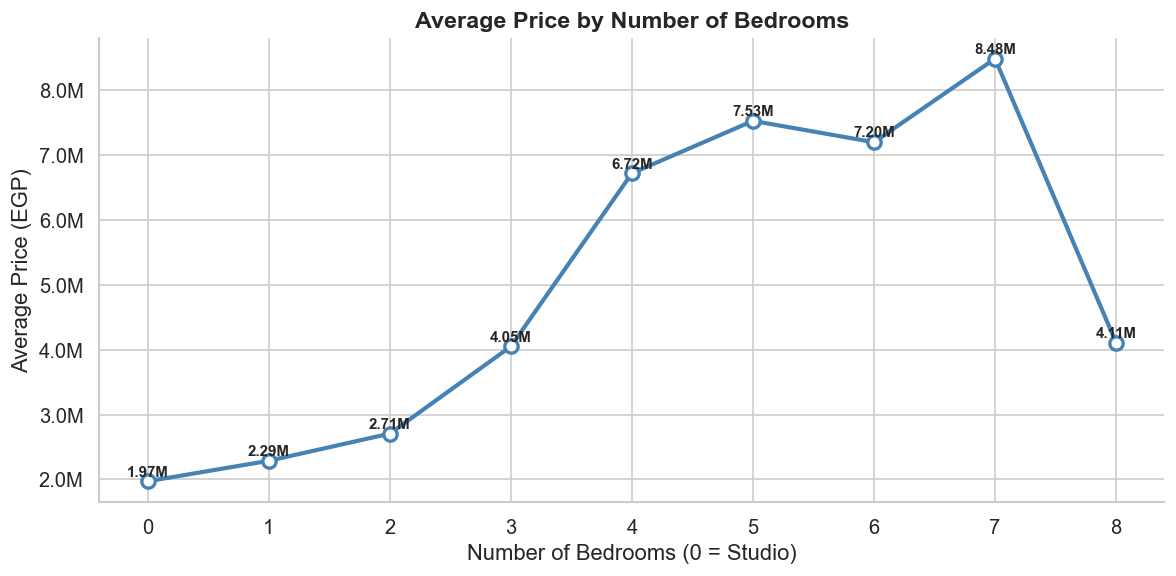

Plot saved.


In [23]:
avg_price_bed = df.groupby('bedroom')['price'].mean().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    avg_price_bed.index.astype(str),
    avg_price_bed.values,
    marker='o', linewidth=2.5,
    color='steelblue', markersize=8,
    markerfacecolor='white', markeredgewidth=2
)

for x, y in zip(avg_price_bed.index.astype(str), avg_price_bed.values):
    ax.text(x, y + 80000, f'{y/1e6:.2f}M', ha='center', fontsize=9, fontweight='bold')

ax.set_title("Average Price by Number of Bedrooms", fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Bedrooms (0 = Studio)")
ax.set_ylabel("Average Price (EGP)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
sns.despine()

plt.tight_layout()
plt.savefig("plot_07_avg_price_by_bedroom.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

### 4.8 Correlation Heatmap
> How strongly do numeric variables relate to each other?

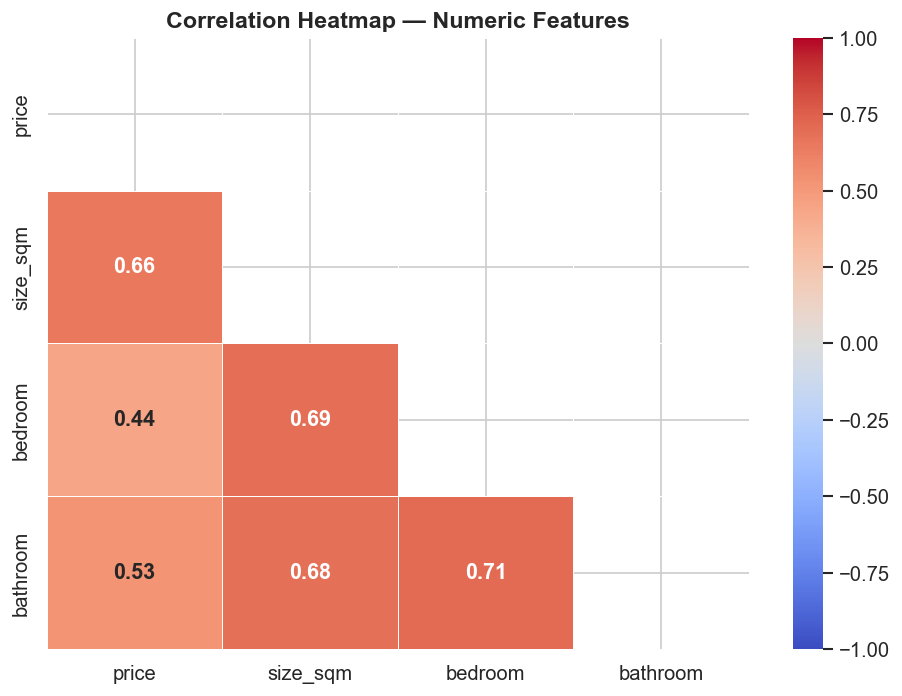

Plot saved.


In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

corr_matrix = df[['price', 'size_sqm', 'bedroom', 'bathroom']].corr()

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    linewidths=0.5,
    annot_kws={'size': 13, 'weight': 'bold'},
    vmin=-1, vmax=1,
    ax=ax
)

ax.set_title("Correlation Heatmap — Numeric Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_08_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

---
##  Section 5: Hypothesis Testing

### Hypothesis 1 — Does Property Type Significantly Affect Price?

**H₀ (Null Hypothesis):** There is no significant difference in price between Villas and Apartments.  
**H₁ (Alternative Hypothesis):** Villas are significantly more expensive than Apartments.  

**Test:** Independent Samples T-Test  
**Significance Level:** α = 0.05

#### Step 1 — Extract the Two Groups

In [25]:
apartments = df[df['type'] == 'Apartment']['price']
villas     = df[df['type'] == 'Villa']['price']

print("Group Summary:")
print("-" * 45)
print(f"  Apartments : {len(apartments):,} listings | mean = {apartments.mean()/1e6:.2f}M EGP | std = {apartments.std()/1e6:.2f}M")
print(f"  Villas     : {len(villas):,} listings | mean = {villas.mean()/1e6:.2f}M EGP | std = {villas.std()/1e6:.2f}M")
print("-" * 45)
print(f"  Mean difference: {(villas.mean() - apartments.mean())/1e6:.2f}M EGP")

Group Summary:
---------------------------------------------
  Apartments : 5,493 listings | mean = 3.13M EGP | std = 1.67M
  Villas     : 1,243 listings | mean = 8.14M EGP | std = 4.19M
---------------------------------------------
  Mean difference: 5.01M EGP


#### Step 2 — Visualize the Two Groups Before Testing

C:\Users\HP\AppData\Local\Temp\ipykernel_15276\58261672.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_to_plot, patch_artist=True,


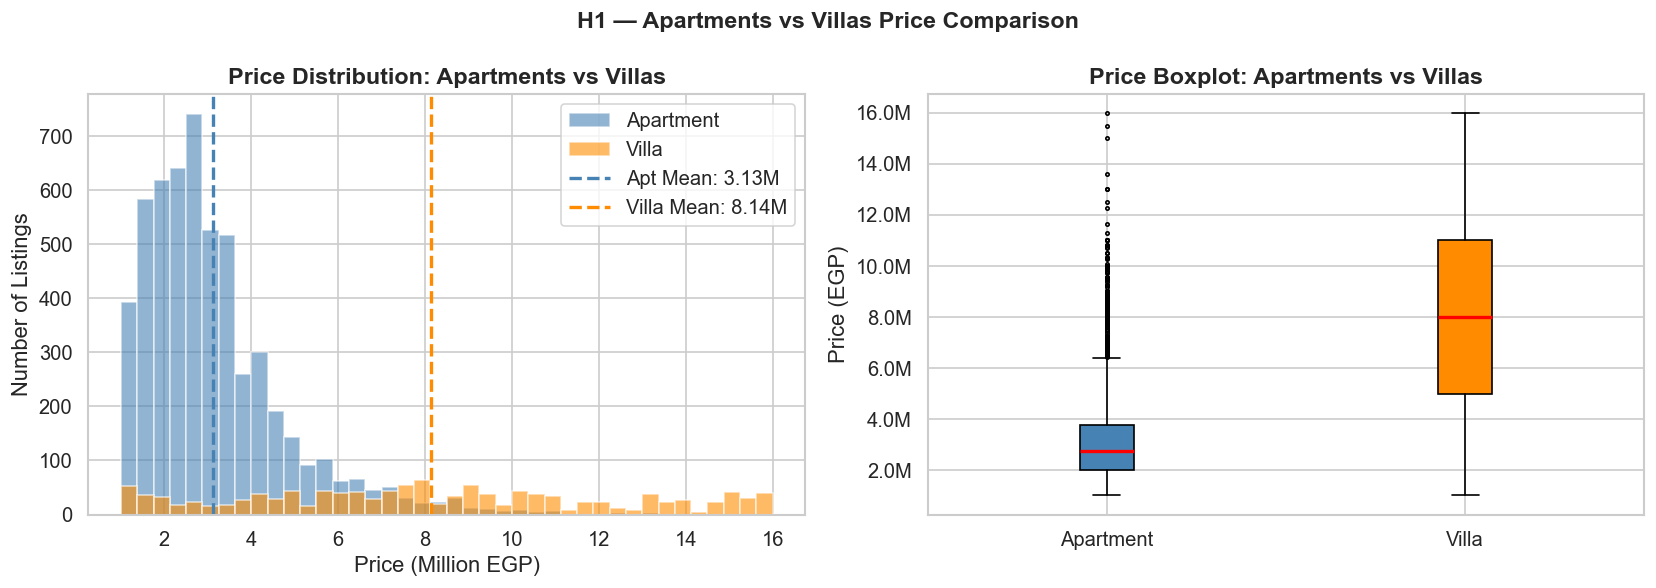

Plot saved.


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Overlapping histograms
axes[0].hist(apartments/1e6, bins=40, alpha=0.6, color='steelblue',
             edgecolor='white', label='Apartment')
axes[0].hist(villas/1e6,     bins=40, alpha=0.6, color='darkorange',
             edgecolor='white', label='Villa')
axes[0].axvline(apartments.mean()/1e6, color='steelblue',
                linestyle='--', linewidth=2, label=f'Apt Mean: {apartments.mean()/1e6:.2f}M')
axes[0].axvline(villas.mean()/1e6,     color='darkorange',
                linestyle='--', linewidth=2, label=f'Villa Mean: {villas.mean()/1e6:.2f}M')
axes[0].set_title("Price Distribution: Apartments vs Villas")
axes[0].set_xlabel("Price (Million EGP)")
axes[0].set_ylabel("Number of Listings")
axes[0].legend()

# -- Side by side boxplots
data_to_plot = [apartments.values, villas.values]
bp = axes[1].boxplot(data_to_plot, patch_artist=True,
                     labels=['Apartment', 'Villa'],
                     medianprops=dict(color='red', linewidth=2),
                     flierprops=dict(marker='o', markersize=2))
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('darkorange')
axes[1].set_title("Price Boxplot: Apartments vs Villas")
axes[1].set_ylabel("Price (EGP)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle("H1 — Apartments vs Villas Price Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_09_h1_visualization.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

#### Step 3 — Run the T-Test

In [27]:
t_stat, p_value = ttest_ind(villas, apartments, equal_var=False)

print("Independent Samples T-Test Results:")
print("=" * 45)
print(f"  T-Statistic : {t_stat:.4f}")
print(f"  P-Value     : {p_value:.6f}")
print("=" * 45)

alpha = 0.05
if p_value < alpha:
    print(f"  Result : p = {p_value:.6f} < alpha = {alpha}")
    print("  Decision : REJECT H0")
    print("  Conclusion : Villas are significantly more")
    print("               expensive than Apartments.")
else:
    print(f"  Result : p = {p_value:.6f} >= alpha = {alpha}")
    print("  Decision : FAIL TO REJECT H0")
    print("  Conclusion : No significant price difference found.")

Independent Samples T-Test Results:
  T-Statistic : 41.4857
  P-Value     : 0.000000
  Result : p = 0.000000 < alpha = 0.05
  Decision : REJECT H0
  Conclusion : Villas are significantly more
               expensive than Apartments.


### Hypothesis 2 — Does Property Size Correlate with Price?

**H₀ (Null Hypothesis):** There is no significant correlation between property size (m²) and price.  
**H₁ (Alternative Hypothesis):** There is a significant positive correlation between property size and price.  

**Test:** Pearson Correlation Coefficient  
**Significance Level:** α = 0.05

#### Step 1 — Calculate the Correlation

In [28]:
corr, p_value = pearsonr(df['size_sqm'], df['price'])

print("Pearson Correlation Results:")
print("=" * 45)
print(f"  Correlation (r) : {corr:.4f}")
print(f"  P-Value         : {p_value:.6f}")
print("=" * 45)

if abs(corr) >= 0.7:
    strength = "Strong"
elif abs(corr) >= 0.4:
    strength = "Moderate"
else:
    strength = "Weak"

direction = "positive" if corr > 0 else "negative"

print(f"  Correlation strength : {strength} {direction}")
print()

alpha = 0.05
if p_value < alpha:
    print(f"  Result   : p = {p_value:.6f} < alpha = {alpha}")
    print("  Decision : REJECT H0")
    print("  Conclusion : Size significantly correlates with price.")
else:
    print(f"  Result   : p = {p_value:.6f} >= alpha = {alpha}")
    print("  Decision : FAIL TO REJECT H0")

Pearson Correlation Results:
  Correlation (r) : 0.6558
  P-Value         : 0.000000
  Correlation strength : Moderate positive

  Result   : p = 0.000000 < alpha = 0.05
  Decision : REJECT H0
  Conclusion : Size significantly correlates with price.


#### Step 2 — Visualize the Correlation

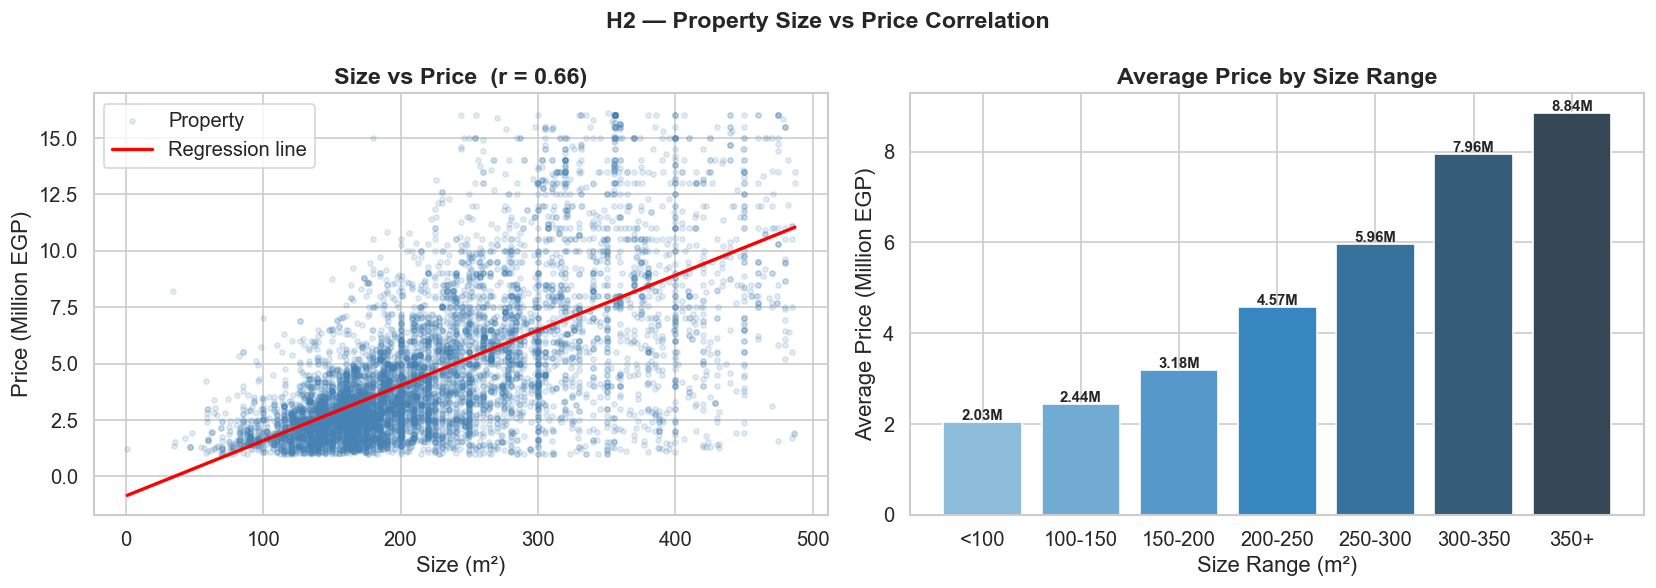

Plot saved.


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Scatter plot with regression line
axes[0].scatter(
    df['size_sqm'], df['price'] / 1e6,
    alpha=0.15, color='steelblue', s=10, label='Property'
)

m, b = np.polyfit(df['size_sqm'], df['price'] / 1e6, 1)
x_line = np.linspace(df['size_sqm'].min(), df['size_sqm'].max(), 200)
axes[0].plot(x_line, m * x_line + b, color='red',
             linewidth=2, label=f'Regression line')

axes[0].set_title(f"Size vs Price  (r = {corr:.2f})")
axes[0].set_xlabel("Size (m²)")
axes[0].set_ylabel("Price (Million EGP)")
axes[0].legend()

# -- Bin size into ranges and show avg price per range
bins = [0, 100, 150, 200, 250, 300, 350, 500]
labels = ['<100', '100-150', '150-200', '200-250', '250-300', '300-350', '350+']
df['size_group'] = pd.cut(df['size_sqm'], bins=bins, labels=labels)
avg_price_size = df.groupby('size_group', observed=True)['price'].mean()

axes[1].bar(
    avg_price_size.index,
    avg_price_size.values / 1e6,
    color=sns.color_palette("Blues_d", len(avg_price_size)),
    edgecolor='white'
)
for i, (label, val) in enumerate(zip(avg_price_size.index, avg_price_size.values)):
    axes[1].text(i, val/1e6 + 0.05, f'{val/1e6:.2f}M',
                 ha='center', fontsize=9, fontweight='bold')

axes[1].set_title("Average Price by Size Range")
axes[1].set_xlabel("Size Range (m²)")
axes[1].set_ylabel("Average Price (Million EGP)")

plt.suptitle("H2 — Property Size vs Price Correlation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_10_h2_correlation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

### Hypothesis 3 — Does Number of Bedrooms Significantly Affect Price?

**H₀ (Null Hypothesis):** There is no significant difference in price across different bedroom counts.  
**H₁ (Alternative Hypothesis):** The number of bedrooms significantly affects the price.  

**Test:** One-Way ANOVA  
**Significance Level:** α = 0.05

#### Step 1 — Prepare Groups & Summary

In [30]:
# Focus on groups with enough data (at least 30 listings)
bedroom_groups = df.groupby('bedroom')['price'].count()
valid_bedrooms  = bedroom_groups[bedroom_groups >= 30].index.tolist()
df_anova        = df[df['bedroom'].isin(valid_bedrooms)]

print("Groups included in ANOVA (min 30 listings):")
print("-" * 50)
for bed in sorted(valid_bedrooms):
    group = df_anova[df_anova['bedroom'] == bed]['price']
    print(f"  {bed} bedroom(s) : {len(group):>5,} listings | mean = {group.mean()/1e6:.2f}M EGP")
print("-" * 50)
print(f"  Total rows used : {len(df_anova):,}")

Groups included in ANOVA (min 30 listings):
--------------------------------------------------
  0 bedroom(s) :    35 listings | mean = 1.97M EGP
  1 bedroom(s) :   133 listings | mean = 2.29M EGP
  2 bedroom(s) : 1,391 listings | mean = 2.71M EGP
  3 bedroom(s) : 5,210 listings | mean = 4.05M EGP
  4 bedroom(s) : 1,891 listings | mean = 6.72M EGP
  5 bedroom(s) :   461 listings | mean = 7.53M EGP
  6 bedroom(s) :    72 listings | mean = 7.20M EGP
--------------------------------------------------
  Total rows used : 9,193


#### Step 2 — Visualize Price by Bedroom Count

C:\Users\HP\AppData\Local\Temp\ipykernel_15276\1574607719.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


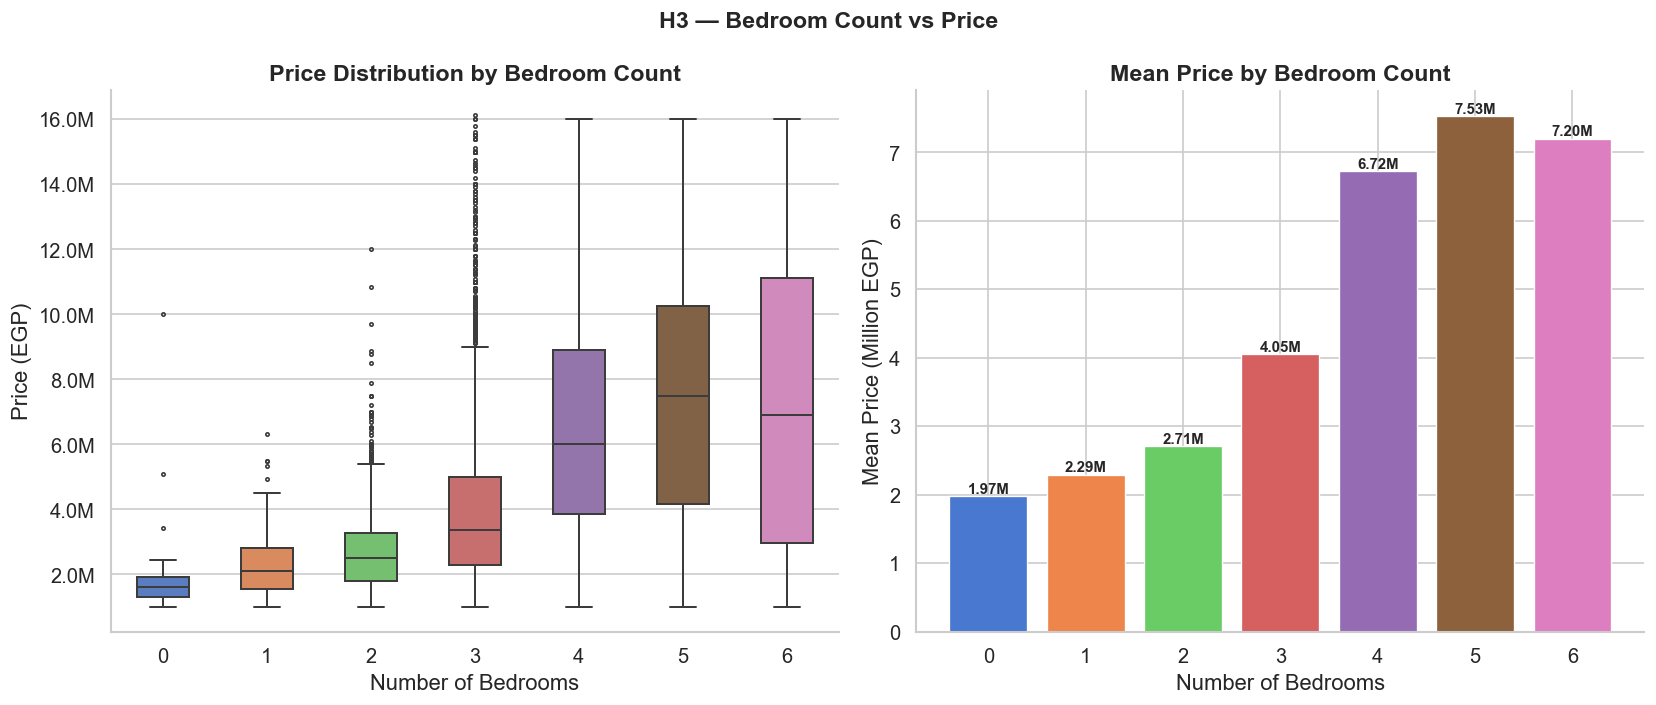

Plot saved.


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

order = sorted(valid_bedrooms)
palette = sns.color_palette("muted", len(order))

# -- Boxplot per bedroom group
sns.boxplot(
    data=df_anova,
    x='bedroom', y='price',
    order=order,
    palette=palette,
    width=0.5,
    linewidth=1.2,
    fliersize=2,
    ax=axes[0]
)
axes[0].set_title("Price Distribution by Bedroom Count")
axes[0].set_xlabel("Number of Bedrooms")
axes[0].set_ylabel("Price (EGP)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# -- Mean price per bedroom (bar)
means = df_anova.groupby('bedroom')['price'].mean()[order]
bars = axes[1].bar(
    [str(b) for b in order],
    means.values / 1e6,
    color=palette,
    edgecolor='white',
    linewidth=0.8
)
for bar, val in zip(bars, means.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{val/1e6:.2f}M',
        ha='center', fontsize=9, fontweight='bold'
    )
axes[1].set_title("Mean Price by Bedroom Count")
axes[1].set_xlabel("Number of Bedrooms")
axes[1].set_ylabel("Mean Price (Million EGP)")
sns.despine()

plt.suptitle("H3 — Bedroom Count vs Price", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_11_h3_visualization.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

#### Step 3 — Run the ANOVA Test

In [32]:
groups = [df_anova[df_anova['bedroom'] == bed]['price'].values
          for bed in sorted(valid_bedrooms)]

f_stat, p_value = f_oneway(*groups)

print("One-Way ANOVA Results:")
print("=" * 45)
print(f"  F-Statistic : {f_stat:.4f}")
print(f"  P-Value     : {p_value:.6f}")
print("=" * 45)

alpha = 0.05
if p_value < alpha:
    print(f"  Result   : p = {p_value:.6f} < alpha = {alpha}")
    print("  Decision : REJECT H0")
    print("  Conclusion : Bedroom count significantly")
    print("               affects property price.")
else:
    print(f"  Result   : p = {p_value:.6f} >= alpha = {alpha}")
    print("  Decision : FAIL TO REJECT H0")
    print("  Conclusion : No significant difference found.")

One-Way ANOVA Results:
  F-Statistic : 437.4324
  P-Value     : 0.000000
  Result   : p = 0.000000 < alpha = 0.05
  Decision : REJECT H0
  Conclusion : Bedroom count significantly
               affects property price.


---
##  Section 6: Conclusions & Summary

### 6.1 Hypothesis Testing Summary

In [33]:
summary = {
    'Hypothesis': [
        'H1: Villas vs Apartments (T-Test)',
        'H2: Size vs Price (Pearson Correlation)',
        'H3: Bedroom Count vs Price (ANOVA)'
    ],
    'Test Used': [
        'Independent T-Test',
        'Pearson Correlation',
        'One-Way ANOVA'
    ],
    'Result': [
        't = 41.49, p < 0.05',
        'r = 0.66, p < 0.05',
        'F = 437.43, p < 0.05'
    ],
    'Decision': [
        'Reject H0',
        'Reject H0',
        'Reject H0'
    ],
    'Conclusion': [
        'Villas significantly more expensive',
        'Strong positive correlation confirmed',
        'More bedrooms = significantly higher price'
    ]
}

summary_df = pd.DataFrame(summary)
print("=" * 90)
print("HYPOTHESIS TESTING SUMMARY")
print("=" * 90)
print(summary_df.to_string(index=False))
print("=" * 90)

HYPOTHESIS TESTING SUMMARY
                             Hypothesis           Test Used               Result  Decision                                 Conclusion
      H1: Villas vs Apartments (T-Test)  Independent T-Test  t = 41.49, p < 0.05 Reject H0        Villas significantly more expensive
H2: Size vs Price (Pearson Correlation) Pearson Correlation   r = 0.66, p < 0.05 Reject H0      Strong positive correlation confirmed
     H3: Bedroom Count vs Price (ANOVA)       One-Way ANOVA F = 437.43, p < 0.05 Reject H0 More bedrooms = significantly higher price


### 6.2 Key Findings

Based on the analysis of **9,209 real Cairo property listings**, the following conclusions were drawn:

**Finding 1 — Property Type is a Major Price Driver**  
Villas (mean: 8.14M EGP) are significantly more expensive than Apartments (mean: 3.13M EGP),  
with a mean difference of **5.01M EGP** (T-statistic = 41.49, p < 0.001).  
Apartments dominate the Cairo market at 59.6% of all listings.

**Finding 2 — Size Strongly Predicts Price**  
A significant moderate-to-strong positive correlation was found between property size and price  
(r = 0.66, p < 0.001). Properties under 100m² average 2.03M EGP, while properties  
above 350m² average 8.84M EGP — a **4x price increase** driven purely by size.

**Finding 3 — More Bedrooms = Higher Price**  
One-Way ANOVA confirmed that bedroom count significantly affects price  
(F = 437.43, p < 0.001). Mean price rises from **1.97M EGP** for Studios  
up to **7.53M EGP** for 5-bedroom properties — a clear, consistent upward trend.

**Overall Conclusion:**  
In Cairo's residential property market, **property type, size, and bedroom count**  
are all statistically significant drivers of price. Among these, property type  
produces the largest absolute price gap, while size shows the strongest  
continuous linear relationship with price.

### 6.3 Dataset Summary After Processing

In [34]:
print("Final Dataset Statistics:")
print("=" * 50)
print(f"  Original rows      : 11,418")
print(f"  After duplicates   : 11,110")
print(f"  After 'Ask' prices : 10,708")
print(f"  After IQR outliers :  9,209")
print(f"  Final clean rows   :  9,209")
print("=" * 50)
print(f"  Price range  : {df['price'].min()/1e6:.2f}M — {df['price'].max()/1e6:.2f}M EGP")
print(f"  Size range   : {df['size_sqm'].min()} — {df['size_sqm'].max()} m²")
print(f"  Bedroom range: {df['bedroom'].min()} — {df['bedroom'].max()}")
print(f"  Property types: {df['type'].nunique()}")
print("=" * 50)
print("All 3 hypotheses: H0 REJECTED at alpha = 0.05")
print("Notebook complete.")

Final Dataset Statistics:
  Original rows      : 11,418
  After duplicates   : 11,110
  After 'Ask' prices : 10,708
  After IQR outliers :  9,209
  Final clean rows   :  9,209
  Price range  : 1.00M — 16.12M EGP
  Size range   : 1 — 487 m²
  Bedroom range: 0 — 8
  Property types: 10
All 3 hypotheses: H0 REJECTED at alpha = 0.05
Notebook complete.
